In [1]:
import kagglehub
import pandas as pd
import numpy as np

# Download latest version
path = kagglehub.dataset_download("burak3ergun/loan-data-set")
print("Path to dataset files:", path)

# The csv inside is usually named loan_data_set.csv
import os
print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "loan_data_set.csv"))
df.head()


100%|██████████| 7.80k/7.80k [00:00<00:00, 5.58MB/s]

Extracting files...
Path to dataset files: /Users/sahibzadahasanatahmad/.cache/kagglehub/datasets/burak3ergun/loan-data-set/versions/1
['loan_data_set.csv']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
# Basic shape and structure
print("Shape:", df.shape)
print(df.info())
print(df.describe())

# Check target distribution
print(df['Loan_Status'].value_counts())
print(df['Loan_Status'].value_counts(normalize=True) * 100)

# Check for missing values
print(df.isnull().sum())

# Check categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", categorical_cols.tolist())

for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())

Shape: (614, 13)
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB
None
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000        

/var/folders/xx/hg7nt6tj1s95wmxgzt5c0hkw0000gn/T/ipykernel_2735/3251930869.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


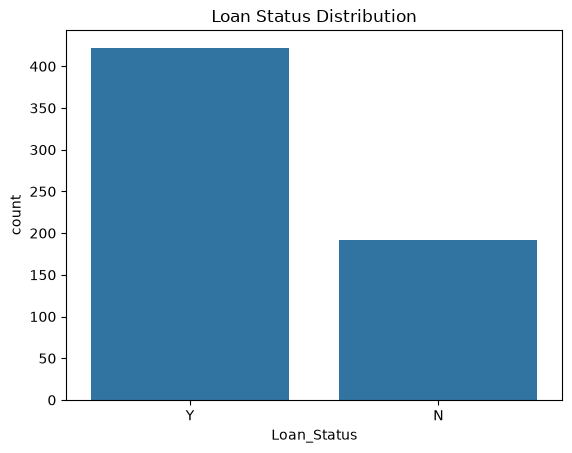

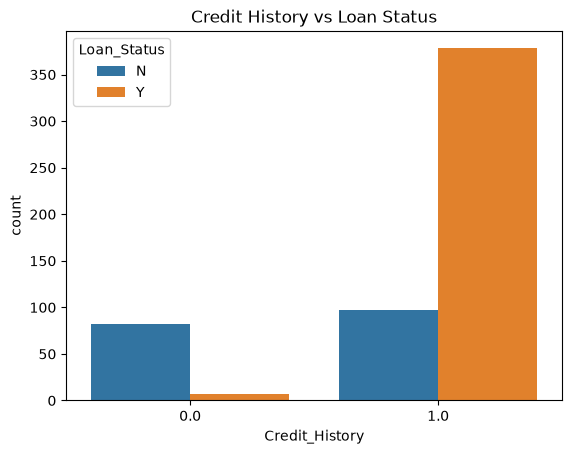

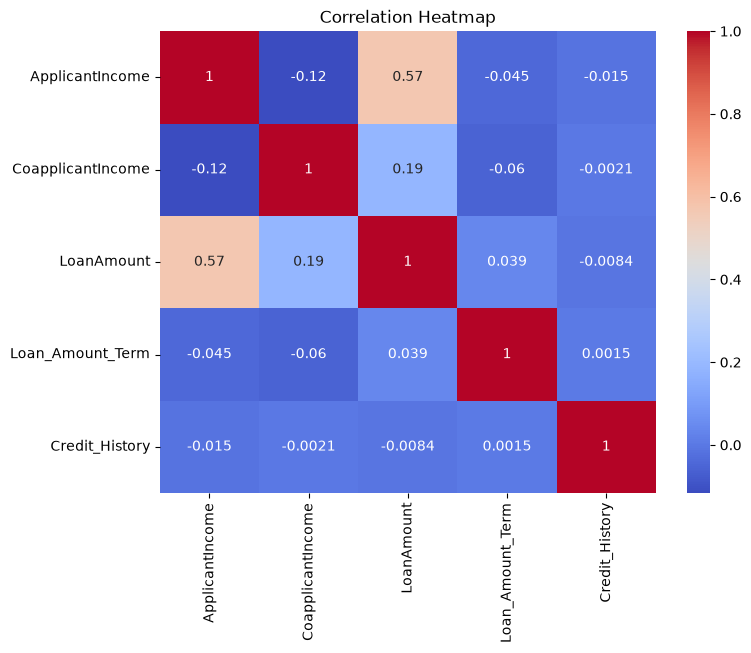

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()

# Credit history vs loan status (typically the strongest predictor)
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

# Correlation among numeric features
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [4]:
# Drop Loan_ID — it's just an identifier, not a predictive feature
df.drop('Loan_ID', axis=1, inplace=True)

# Fill missing values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

# Clean Dependents column ("3+" -> 3)
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])   # e.g. Loan_Status: N=0, Y=1

# Property_Area has 3 categories -> one-hot encode
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

df.head()

/var/folders/xx/hg7nt6tj1s95wmxgzt5c0hkw0000gn/T/ipykernel_2735/1163484658.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/var/folders/xx/hg7nt6tj1s95wmxgzt5c0hkw0000gn/T/ipykernel_2735/1163484658.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame

ValueError: cannot convert float NaN to integer

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred
results['Actual_Label'] = results['Actual'].map({0: 'Not Fully Paid', 1: 'Fully Paid'})
results['Predicted_Label'] = results['Predicted'].map({0: 'Not Fully Paid', 1: 'Fully Paid'})

print(results[['Actual_Label', 'Predicted_Label']].head(10))